In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from matplotlib.lines import Line2D

In [2]:
def compute_arc(x0, y0, theta0, x1, y1):
    """
    Find the unique circular arc from (x0,y0) tangent to heading theta0
    that passes through goal (x1,y1).

    Returns
    -------
    theta1 : float  - arrival heading at the goal (radians)
    r      : float  - signed radius (+ left/CCW turn, - right/CW turn, inf = straight)
    Cx, Cy : float  - turning circle center (None if straight)
    """
    dx, dy = x1 - x0, y1 - y0
    denom = dx * np.sin(theta0) - dy * np.cos(theta0)

    if abs(denom) < 1e-6:  # goal is directly ahead: straight line
        return np.arctan2(dy, dx), np.inf, None, None

    r  = -(dx**2 + dy**2) / (2 * denom)
    Cx = x0 - r * np.sin(theta0)
    Cy = y0 + r * np.cos(theta0)

    # tangent to circle at goal, in the direction of travel
    rx, ry = x1 - Cx, y1 - Cy
    if r > 0:   # CCW: tangent = radial rotated +90°
        theta1 = np.arctan2(rx, -ry)
    else:       # CW:  tangent = radial rotated -90°
        theta1 = np.arctan2(-rx, ry)

    return theta1, r, Cx, Cy


def arc_angles(x0, y0, x1, y1, Cx, Cy, r):
    """Return angle array for drawing the arc from P0 to P1 on the turning circle."""
    a0 = np.arctan2(y0 - Cy, x0 - Cx)
    a1 = np.arctan2(y1 - Cy, x1 - Cx)
    if r > 0:          # CCW: angles must increase
        if a1 <= a0:
            a1 += 2 * np.pi
    else:              # CW: angles must decrease
        if a1 >= a0:
            a1 -= 2 * np.pi
    return np.linspace(a0, a1, 400)


def arrow(ax, x, y, theta, length, color, lw=2.5, zorder=7):
    ax.annotate('',
        xy=(x + length * np.cos(theta), y + length * np.sin(theta)),
        xytext=(x, y),
        arrowprops=dict(arrowstyle='->', color=color, lw=lw),
        zorder=zorder)

In [ ]:
def visualize(theta0_deg, x1, y1):
    x0, y0 = 0.0, 0.0
    theta0 = np.radians(theta0_deg)

    theta1_arc, r, Cx, Cy = compute_arc(x0, y0, theta0, x1, y1)
    theta1_simple = np.arctan2(y1 - y0, x1 - x0)  # straight-line heading

    bearing = np.degrees(np.arctan2(y1 - y0, x1 - x0))
    misalign = ((theta0_deg - bearing) + 180) % 360 - 180  # signed misalignment

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

    arrow_len = 0.22

    # --- turning circle and arc ---
    if np.isfinite(r) and Cx is not None:
        circ = plt.Circle((Cx, Cy), abs(r), color='gray', fill=False,
                          linestyle='--', alpha=0.35, zorder=3)
        ax.add_patch(circ)
        ax.plot(Cx, Cy, '+', color='gray', markersize=10, zorder=4,
                label=f'Circle center  r={abs(r):.2f} m')

        angs = arc_angles(x0, y0, x1, y1, Cx, Cy, r)
        arc_x = Cx + abs(r) * np.cos(angs)
        arc_y = Cy + abs(r) * np.sin(angs)
        ax.plot(arc_x, arc_y, 'b-', lw=2.5, zorder=5, label='Natural arc path')
    else:
        ax.plot([x0, x1], [y0, y1], 'b-', lw=2.5, zorder=5, label='Straight path')

    # --- rover start ---
    ax.plot(x0, y0, 'o', color='green', markersize=11, zorder=6)
    arrow(ax, x0, y0, theta0, arrow_len, 'green')
    ax.text(x0 + 0.06, y0 + 0.1,
            f'Start\nθ₀ = {theta0_deg:.0f}°', color='green', fontsize=10)

    # --- goal ---
    ax.plot(x1, y1, 'r*', markersize=16, zorder=6)

    # arc-based arrival heading
    arrow(ax, x1, y1, theta1_arc, arrow_len, 'red', lw=2.5)
    ax.text(x1 + 0.08, y1 + 0.12,
            f'Arc: θ₁ = {np.degrees(theta1_arc):.0f}°',
            color='red', fontsize=10, fontweight='bold')

    # simple (straight-line) heading - only draw if meaningfully different
    angle_diff = abs(((np.degrees(theta1_arc) - np.degrees(theta1_simple)) + 180) % 360 - 180)
    if angle_diff > 2.0:
        arrow(ax, x1, y1, theta1_simple, arrow_len, 'darkorange', lw=2.5)
        ax.text(x1 + 0.08, y1 - 0.18,
                f'Simple: θ₁ = {np.degrees(theta1_simple):.0f}°',
                color='darkorange', fontsize=10)

    # --- legend ---
    legend_items = [
        Line2D([0],[0], color='b',          lw=2.5, label='Natural arc path'),
        Line2D([0],[0], color='green',      lw=2.5, label='Start heading'),
        Line2D([0],[0], color='red',        lw=2.5, label='Arc-based arrival θ (proposed)'),
        Line2D([0],[0], color='darkorange', lw=2.5, label='Simple arrival θ (straight-line dir)'),
        Line2D([0],[0], color='gray',       lw=1.5, linestyle='--', label='Turning circle'),
    ]
    ax.legend(handles=legend_items, fontsize=9, loc='upper left')

    ax.set_title(
        f'Rover at (0,0) heading {theta0_deg:.0f}°  |  '
        f'Goal ({x1:.1f}, {y1:.1f})  |  '
        f'Misalignment: {misalign:.0f}°  |  '
        f'Arc Δθ: {angle_diff:.0f}°',
        fontsize=11
    )

    # auto-range
    pts_x = [x0, x1, Cx] if (Cx is not None and np.isfinite(r)) else [x0, x1]
    pts_y = [y0, y1, Cy] if (Cy is not None and np.isfinite(r)) else [y0, y1]
    pad = min(max(abs(r) if np.isfinite(r) else 0, 1.0) * 0.35 + 0.5, 4.0)
    ax.set_xlim(min(pts_x) - pad, max(pts_x) + pad)
    ax.set_ylim(min(pts_y) - pad, max(pts_y) + pad)

    plt.tight_layout()
    plt.show()


widgets.interact(
    visualize,
    theta0_deg=widgets.FloatSlider(
        value=60.0, min=-180, max=180, step=5,
        description='θ₀ rover (deg)',
        style={'description_width': 'initial'}, layout={'width': '450px'}
    ),
    x1=widgets.FloatSlider(
        value=2.0, min=-3.0, max=4.0, step=0.1,
        description='Goal x (m)',
        style={'description_width': 'initial'}, layout={'width': '450px'}
    ),
    y1=widgets.FloatSlider(
        value=0.5, min=-3.0, max=3.0, step=0.1,
        description='Goal y (m)',
        style={'description_width': 'initial'}, layout={'width': '450px'}
    ),
)

interactive(children=(FloatSlider(value=60.0, description='θ₀ rover (deg)', layout=Layout(width='450px'), max=…

<function __main__.visualize(theta0_deg, x1, y1)>

## Static comparison: aligned vs misaligned

Four scenarios showing how the arc-based arrival heading (red) vs simple heading (orange) diverge as misalignment increases.

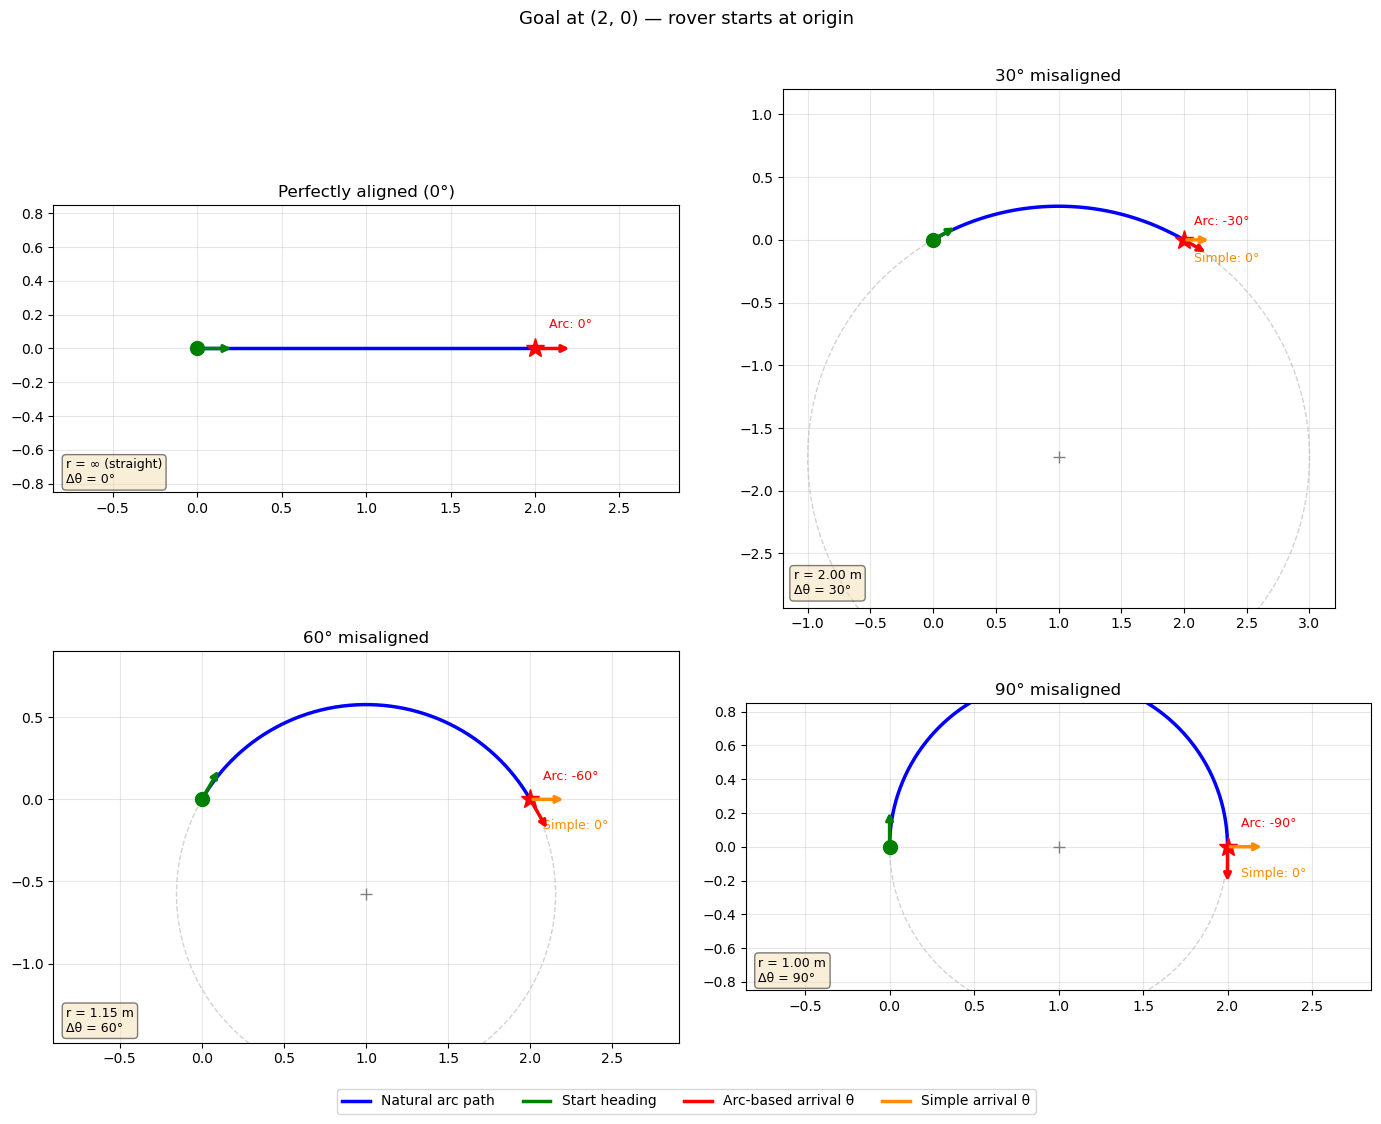

In [4]:
scenarios = [
    (0,   2.0, 0.0,  'Perfectly aligned (0°)'),
    (30,  2.0, 0.0,  '30° misaligned'),
    (60,  2.0, 0.0,  '60° misaligned'),
    (90,  2.0, 0.0,  '90° misaligned'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
arrow_len = 0.22

for ax, (theta0_deg, x1, y1, title) in zip(axes.flat, scenarios):
    x0, y0 = 0.0, 0.0
    theta0 = np.radians(theta0_deg)

    theta1_arc, r, Cx, Cy = compute_arc(x0, y0, theta0, x1, y1)
    theta1_simple = np.arctan2(y1, x1)
    angle_diff = abs(((np.degrees(theta1_arc) - np.degrees(theta1_simple)) + 180) % 360 - 180)

    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title(title, fontsize=12)

    if np.isfinite(r) and Cx is not None:
        circ = plt.Circle((Cx, Cy), abs(r), color='gray', fill=False,
                          linestyle='--', alpha=0.35)
        ax.add_patch(circ)
        ax.plot(Cx, Cy, '+', color='gray', markersize=8)
        angs = arc_angles(x0, y0, x1, y1, Cx, Cy, r)
        ax.plot(Cx + abs(r)*np.cos(angs), Cy + abs(r)*np.sin(angs),
                'b-', lw=2.5, label='Arc path')
    else:
        ax.plot([x0, x1], [y0, y1], 'b-', lw=2.5, label='Straight')

    ax.plot(x0, y0, 'o', color='green', markersize=10, zorder=6)
    ax.annotate('', xy=(x0+arrow_len*np.cos(theta0), y0+arrow_len*np.sin(theta0)),
                xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color='green', lw=2.5), zorder=7)

    ax.plot(x1, y1, 'r*', markersize=14, zorder=6)

    ax.annotate('', xy=(x1+arrow_len*np.cos(theta1_arc), y1+arrow_len*np.sin(theta1_arc)),
                xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='red', lw=2.5), zorder=7)
    ax.text(x1+0.08, y1+0.12,
            f'Arc: {np.degrees(theta1_arc):.0f}°', color='red', fontsize=9)

    if angle_diff > 1.0:
        ax.annotate('', xy=(x1+arrow_len*np.cos(theta1_simple), y1+arrow_len*np.sin(theta1_simple)),
                    xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color='darkorange', lw=2.5), zorder=7)
        ax.text(x1+0.08, y1-0.18,
                f'Simple: {np.degrees(theta1_simple):.0f}°', color='darkorange', fontsize=9)

    r_label = f'{abs(r):.2f} m' if np.isfinite(r) else '∞ (straight)'
    ax.text(0.02, 0.02, f'r = {r_label}\nΔθ = {angle_diff:.0f}°',
            transform=ax.transAxes, fontsize=9, verticalalignment='bottom',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    pts_x = [x0, x1, Cx] if (Cx is not None and np.isfinite(r)) else [x0, x1]
    pts_y = [y0, y1, Cy] if (Cy is not None and np.isfinite(r)) else [y0, y1]
    pad = min(max(abs(r) if np.isfinite(r) else 0, 1.0) * 0.35 + 0.5, 3.0)
    ax.set_xlim(min(pts_x) - pad, max(pts_x) + pad)
    ax.set_ylim(min(pts_y) - pad, max(pts_y) + pad)

legend_items = [
    Line2D([0],[0], color='b',          lw=2.5, label='Natural arc path'),
    Line2D([0],[0], color='green',      lw=2.5, label='Start heading'),
    Line2D([0],[0], color='red',        lw=2.5, label='Arc-based arrival θ'),
    Line2D([0],[0], color='darkorange', lw=2.5, label='Simple arrival θ'),
]
fig.legend(handles=legend_items, fontsize=10, loc='lower center',
           ncol=4, bbox_to_anchor=(0.5, 0.0))
plt.suptitle('Goal at (2, 0) — rover starts at origin', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()